In [14]:
import pandas as pd

result_path = "NIAID-Qwen3VL-4B-20260719-171650" # handwritten image
# result_path = "NIAID-Qwen3VL-4B-20260720-220204" # rdkit image

data_df = pd.read_json(f"data/exp/{result_path}.jsonl", lines=True)

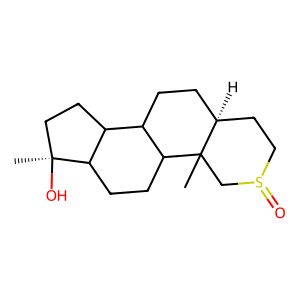

('C[C@@]1(CCC2C1CCC3C2CC[C@@H]4C3(CS(=O)CC4)C)O',
 None,
 (300, 300))

In [15]:
from rdkit import Chem
from rdkit.Chem import Draw

mol = data_df["ground_truth"][0]
mol = Chem.MolFromSmiles(mol)
img = Draw.MolToImage(mol)

data_df["ground_truth"][0], mol, img.show(), img.size

In [16]:
mol = data_df["output_text"][0]
mol = Chem.MolFromSmiles(mol)

data_df["output_text"][0], mol

[19:34:49] SMILES Parse Error: duplicated ring closure 1 bonds atom 11 to itself for input: 'O=S1C2C3C4C5C6C7C8C9C10C11C12C13C14C15C16C17C18C19C20C21C22C23C24C25C26C27C28C29C30C31C32C33C34C35C36C37C38C39C40C41C42C43C44C45C46C47C48C49C50C51C52C53C54C55C56C57C58C59C60C61C62C63C64C65C66C67C68C69C70C71C72C73C74C75C76C77C78C79C80C81C82C83C84C85C86C87C88'


('O=S1C2C3C4C5C6C7C8C9C10C11C12C13C14C15C16C17C18C19C20C21C22C23C24C25C26C27C28C29C30C31C32C33C34C35C36C37C38C39C40C41C42C43C44C45C46C47C48C49C50C51C52C53C54C55C56C57C58C59C60C61C62C63C64C65C66C67C68C69C70C71C72C73C74C75C76C77C78C79C80C81C82C83C84C85C86C87C88',
 None)

In [17]:
from PIL import Image

img_pil = Image.open(data_df["image_path"][0])
# handwritten_img_pil = Image.open(data_df["handwritten_image_path"][0])

# img_pil.show(), handwritten_img_pil.show()

In [18]:
# data_df.head()

In [ ]:
# valid ratio
# This dataset is already close to raw SMILES, so we only do light normalization.
# Trim outer whitespace/quotes and remove any stray inner whitespace.

def clean_smiles_text(text):
    if pd.isna(text):
        return None
    cleaned = str(text).strip()
    cleaned = cleaned.strip("`'\"")
    cleaned = "".join(cleaned.split())
    return cleaned or None


def smiles_to_mol(smiles):
    if smiles is None:
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None


def mol_to_canonical_smiles(mol):
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None


def mol_to_inchikey(mol):
    if mol is None:
        return None
    try:
        return Chem.MolToInchiKey(mol)
    except Exception:
        return None


def build_smiles_cols(text_series):
    raw = text_series.copy()
    clean = raw.map(clean_smiles_text)
    mol = clean.map(smiles_to_mol)
    canonical = mol.map(mol_to_canonical_smiles)
    inchikey = mol.map(mol_to_inchikey)
    valid = mol.notna()
    return pd.DataFrame(
        {
            "raw": raw,
            "clean": clean,
            "mol": mol,
            "canonical": canonical,
            "inchikey": inchikey,
            "valid": valid,
        },
        index=text_series.index,
    )


gt_cols = build_smiles_cols(data_df["ground_truth"])
pred_cols = build_smiles_cols(data_df["output_text"])

# Expand the dataframe with comparable OCR evaluation columns.
data_df = data_df.assign(
    gt_smiles_raw=gt_cols["raw"],
    gt_smiles_clean=gt_cols["clean"],
    gt_mol=gt_cols["mol"],
    gt_canonical_smiles=gt_cols["canonical"],
    gt_inchikey=gt_cols["inchikey"],
    gt_valid_smiles=gt_cols["valid"],
    pred_smiles_raw=pred_cols["raw"],
    pred_smiles_clean=pred_cols["clean"],
    pred_mol=pred_cols["mol"],
    pred_canonical_smiles=pred_cols["canonical"],
    pred_inchikey=pred_cols["inchikey"],
    pred_valid_smiles=pred_cols["valid"],
)

data_df["smiles_exact_match"] = data_df["gt_smiles_clean"].eq(data_df["pred_smiles_clean"])
data_df["smiles_canonical_match"] = data_df["gt_canonical_smiles"].eq(data_df["pred_canonical_smiles"])
data_df["smiles_inchikey_match"] = data_df["gt_inchikey"].eq(data_df["pred_inchikey"])
data_df["smiles_pair_valid"] = data_df["gt_valid_smiles"] & data_df["pred_valid_smiles"]
data_df["ocr_smiles_hit"] = data_df["smiles_pair_valid"] & data_df["smiles_inchikey_match"]

data_df[[
    "gt_smiles_raw",
    "gt_smiles_clean",
    "gt_canonical_smiles",
    "gt_inchikey",
    "gt_valid_smiles",
    "pred_smiles_raw",
    "pred_smiles_clean",
    "pred_canonical_smiles",
    "pred_inchikey",
    "pred_valid_smiles",
    "smiles_exact_match",
    "smiles_canonical_match",
    "smiles_inchikey_match",
    "smiles_pair_valid",
    "ocr_smiles_hit",
]].head()

[19:34:49] Explicit valence for atom # 2 Kr, 2, is greater than permitted
[19:34:49] Explicit valence for atom # 8 Ar, 2, is greater than permitted
[19:34:50] SMILES Parse Error: duplicated ring closure 1 bonds atom 11 to itself for input: 'O=S1C2C3C4C5C6C7C8C9C10C11C12C13C14C15C16C17C18C19C20C21C22C23C24C25C26C27C28C29C30C31C32C33C34C35C36C37C38C39C40C41C42C43C44C45C46C47C48C49C50C51C52C53C54C55C56C57C58C59C60C61C62C63C64C65C66C67C68C69C70C71C72C73C74C75C76C77C78C79C80C81C82C83C84C85C86C87C88'
[19:34:50] SMILES Parse Error: ring closure 1 duplicates bond between atom 54 and atom 59 for input: 'C1=CC=C(C=C1)C2=CC=CC=C2C3=CC=CC=C3C4=CC=CC=C4C5=CC=CC=C5C6=CC=CC=C6C7=CC=CC=C7C8=CC=CC=C8C9=CC=CC=C9C10=CC=CC=C10C11=CC=CC=C11C12=CC=CC=C12C13=CC=CC=C13C14=CC=CC=C14C15=CC=CC=C15C16=CC=CC=C16C17=CC=CC=C17C18=CC=CC=C18C19=CC=CC=C19C20=CC=CC=C20C21=CC=CC=C21C22=CC=CC=C22C23=CC=CC=C23C24=CC=CC=C24C25=CC=CC=C25C26=CC=CC=C26C27=CC=CC=C27C28'
[19:34:50] SMILES Parse Error: syntax error while parsing:

,gt_smiles_raw,gt_smiles_clean,gt_canonical_smiles,gt_inchikey,gt_valid_smiles,pred_smiles_raw,pred_smiles_clean,pred_canonical_smiles,pred_inchikey,pred_valid_smiles,smiles_exact_match,smiles_canonical_match,smiles_inchikey_match,smiles_pair_valid,ocr_smiles_hit
0,C[C@@]1(CCC2C1CCC3C2CC[C@@H]4C3(CS(=O)CC4)C)O,C[C@@]1(CCC2C1CCC3C2CC[C@@H]4C3(CS(=O)CC4)C)O,CC12CS(=O)CC[C@@H]1CCC1C3CC[C@](C)(O)C3CCC12,PVXPJHMXQHTXIS-UYOPTZLXSA-N,True,O=S1C2C3C4C5C6C7C8C9C10C11C12C13C14C15C16C17C1...,O=S1C2C3C4C5C6C7C8C9C10C11C12C13C14C15C16C17C1...,NaN,NaN,False,False,False,False,False,False
1,B(C(C)(C)C)(C(C)(C)C)N,B(C(C)(C)C)(C(C)(C)C)N,CC(C)(C)B(N)C(C)(C)C,FDGBAQRKBJOKSB-UHFFFAOYSA-N,True,CC(C)(C)B(N)N,CC(C)(C)B(N)N,CC(C)(C)B(N)N,CPEXSWLXZZVSEJ-UHFFFAOYSA-N,True,False,False,False,True,False
2,CC(C)(CCC(F)(F)Br)C(=O)[O-],CC(C)(CCC(F)(F)Br)C(=O)[O-],CC(C)(CCC(F)(F)Br)C(=O)[O-],NDLZHIZXAMTTEA-UHFFFAOYSA-M,True,CC(C)(C(=O)O)CC(F)(F)Br,CC(C)(C(=O)O)CC(F)(F)Br,CC(C)(CC(F)(F)Br)C(=O)O,LSLKEJSUEIYYAX-UHFFFAOYSA-N,True,False,False,False,True,False
3,C1C2=CC=CC=C2[C@@H]([C@@H](C3=CC=CC=C31)O)CCN,C1C2=CC=CC=C2[C@@H]([C@@H](C3=CC=CC=C31)O)CCN,NCC[C@H]1c2ccccc2Cc2ccccc2[C@H]1O,KGMVLMJYRNGYMP-DLBZAZTESA-N,True,C1=CC=C(C=C1)C2=CC=CC=C2C3=CC=CC=C3C4=CC=CC=C4...,C1=CC=C(C=C1)C2=CC=CC=C2C3=CC=CC=C3C4=CC=CC=C4...,NaN,NaN,False,False,False,False,False,False
4,CC(NS(=O)(=O)C)N(C(=O)O)C(C)(C)C,CC(NS(=O)(=O)C)N(C(=O)O)C(C)(C)C,CC(NS(C)(=O)=O)N(C(=O)O)C(C)(C)C,GWTQKQICNJSKBM-UHFFFAOYSA-N,True,CC(C)(C)N(C(=O)O)C(C)NS(=O)(=O),CC(C)(C)N(C(=O)O)C(C)NS(=O)(=O),CC(N[SH](=O)=O)N(C(=O)O)C(C)(C)C,LBBQLXIMUMOKPL-UHFFFAOYSA-N,True,False,False,False,True,False


In [20]:
metrics = pd.Series(
    {
        "gt_valid_rate": data_df["gt_valid_smiles"].mean(),
        "pred_valid_rate": data_df["pred_valid_smiles"].mean(),
        # "smiles_pair_valid_rate": data_df["smiles_pair_valid"].mean(),
        # "smiles_exact_match_rate": data_df["smiles_exact_match"].mean(),
        "smiles_canonical_match_rate": data_df["smiles_canonical_match"].mean(),
        "smiles_inchikey_match_rate": data_df["smiles_inchikey_match"].mean(),
        # "ocr_smiles_hit_rate": data_df["ocr_smiles_hit"].mean(),
    }
)

metrics

gt_valid_rate                  0.998035
pred_valid_rate                0.596267
smiles_canonical_match_rate    0.005894
smiles_inchikey_match_rate     0.005894
dtype: float64